# Phân tích dữ liệu Spotify Global và Vietnam

###  Giới thiệu bài toán


##### Spotify là một trong những nền tảng nghe nhạc trực tuyến phổ biến nhất hiện nay. Dữ liệu từ bảng xếp hạng Spotify phản ánh mức độ phổ biến của các bài hát và nghệ sĩ thông qua các chỉ số như số lượt streams và số tuần xuất hiện trên bảng xếp hạng. 

Bài báo cáo này, tiến hành phân tích dữ liệu Spotify Global và Spotify Vietnam nhằm tìm hiểu xu hướng nghe nhạc, đồng thời so sánh sự khác biệt giữa thị trường âm nhạc toàn cầu và thị trường Việt Nam thông qua các phương pháp trực quan hóa dữ liệu.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Quốc tế

# Đọc dữ liệu

In [24]:
spotify = pd.read_json(r"D:\Spotify data\result\Global_1541.json")

spotify.head()

,rank,uri,artist_names,track_name,source,peak_rank,previous_rank,weeks_on_chart,streams
0,1,spotify:track:3sK8wGT43QFpWrvNQsrQya,Bad Bunny,DtMF,Rimas Entertainment LLC.,1,1,61,39131995
1,2,spotify:track:1DwscornXpj8fmOmYVlqZt,"PinkPantheress, Zara Larsson",Stateside + Zara Larsson,Warner Records,2,11,8,38913426
2,3,spotify:track:5y2ijHECwFYWqcAHKTZgzD,Bruno Mars,Risk It All,Atlantic Records,3,-1,1,36569896
3,4,spotify:track:3qhlB30KknSejmIvZZLjOD,Djo,End of Beginning,Djo,1,3,107,31777044
4,5,spotify:track:1qbmS6ep2hbBRaEZFpn7BX,Olivia Dean,Man I Need,PLG - Capitol,3,5,28,31301570


# Xem cấu trúc dữ liệu

In [26]:
spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   rank            200 non-null    int64 
 1   uri             200 non-null    object
 2   artist_names    200 non-null    object
 3   track_name      200 non-null    object
 4   source          200 non-null    object
 5   peak_rank       200 non-null    int64 
 6   previous_rank   200 non-null    int64 
 7   weeks_on_chart  200 non-null    int64 
 8   streams         200 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 14.2+ KB


##### Dataset Spotify Global gồm nhiều cột thông tin như tên bài hát, nghệ sĩ, số lượt streams, số tuần trên bảng xếp hạng và nguồn phát hành. Dữ liệu này giúp phân tích mức độ phổ biến của các bài hát trên Spotify.

# Thống kê dữ liệu 

In [29]:
spotify.describe()

,rank,peak_rank,previous_rank,weeks_on_chart,streams
count,200.000000,200.000000,200.000000,200.000000,2.000000e+02
mean,100.500000,43.825000,80.005000,76.390000,1.291454e+07
std,57.879185,46.296449,58.828129,83.070702,5.914588e+06
min,1.000000,1.000000,-1.000000,1.000000,8.438961e+06
25%,50.750000,6.000000,26.750000,15.000000,9.354643e+06
50%,100.500000,27.500000,77.500000,48.500000,1.075583e+07
75%,150.250000,70.250000,129.250000,107.000000,1.363222e+07
max,200.000000,187.000000,197.000000,437.000000,3.913200e+07


##### Thống kê mô tả cho thấy sự phân bố của các biến số trong dataset. Đặc biệt, số lượt streams có sự chênh lệch lớn giữa các bài hát, cho thấy một số bài hit có lượng nghe vượt trội.

# Số hóa

In [32]:
spotify["streams"] = spotify["streams"].astype(int)
spotify["rank"] = spotify["rank"].astype(int)
spotify["weeks_on_chart"] = spotify["weeks_on_chart"].astype(int)

# Phân tích số lượt streams


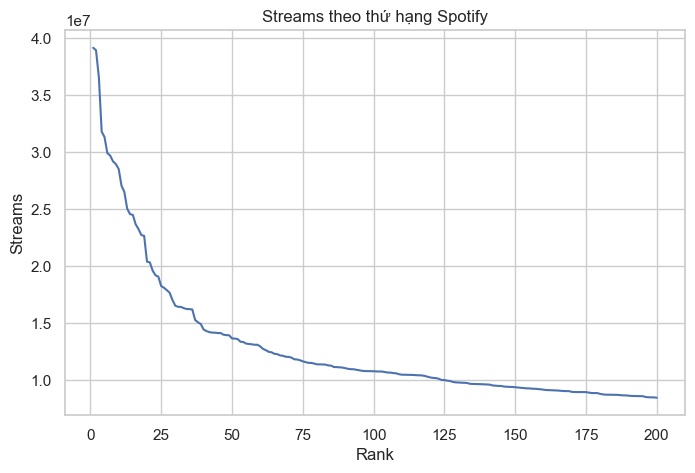

In [34]:
plt.figure(figsize=(8,5))

sorted_data = spotify.sort_values("rank")

plt.plot(sorted_data["rank"], sorted_data["streams"])

plt.title("Streams theo thứ hạng Spotify")
plt.xlabel("Rank")
plt.ylabel("Streams")

plt.show()

# Phân tích tỉ lệ Source phát hành

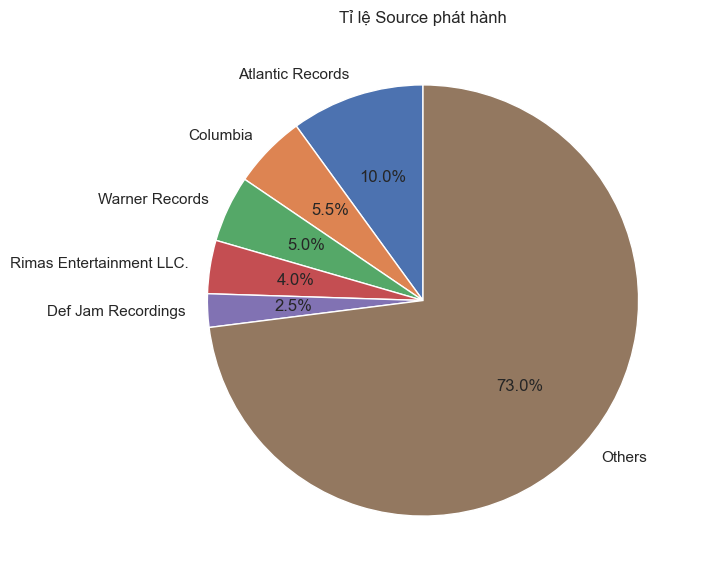

In [36]:
plt.figure(figsize=(7,7))

source_counts = spotify["source"].value_counts()

top5 = source_counts.head(5)
others = source_counts[5:].sum()

data = list(top5.values) + [others]
labels = list(top5.index) + ["Others"]

plt.pie(
    data,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Tỉ lệ Source phát hành")

plt.show()

##### Biểu đồ thể hiện tỉ lệ các nguồn phát hành bài hát trên Spotify. Phần lớn bài hát đến từ các single hoặc album chính thức của nghệ sĩ.

# Top 10 bài hát theo số lượt Streams

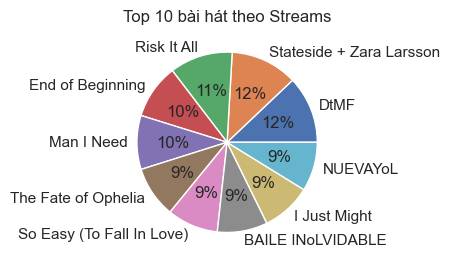

In [39]:
# Pie chart Rank
plt.subplot(1,2,2)

top10 = spotify.nsmallest(10,"rank")

plt.pie(top10["streams"],
        labels=top10["track_name"],
        autopct='%1.0f%%')

plt.title("Top 10 bài hát theo Streams")

plt.show()

##### Top 10 bài hát có số lượt streams cao nhất đại diện cho những bản hit phổ biến nhất trên Spotify. Những bài hát này thường có sức ảnh hưởng lớn và được nghe nhiều trên toàn cầu.

# Nghệ sĩ có nhiều bài hát trên chart

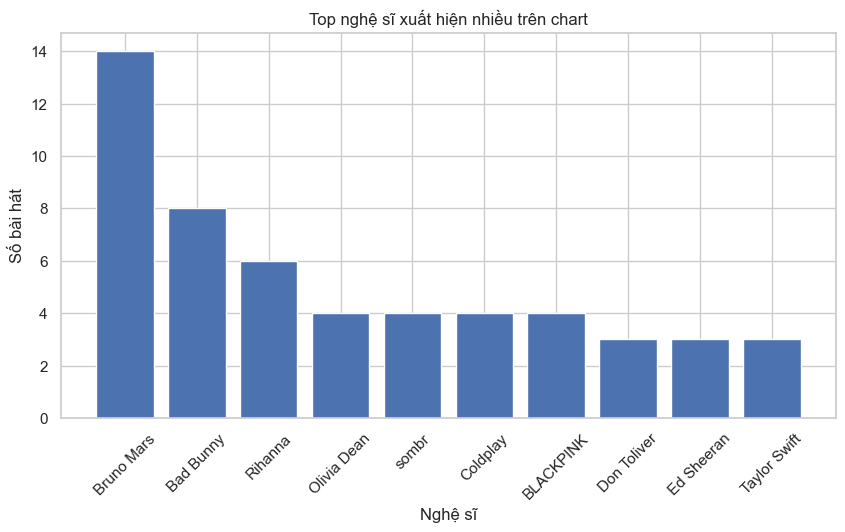

In [42]:
artist_count = spotify["artist_names"].value_counts().head(10)

plt.figure(figsize=(10,5))

plt.bar(artist_count.index, artist_count.values)

plt.title("Top nghệ sĩ xuất hiện nhiều trên chart")
plt.xlabel("Nghệ sĩ")
plt.ylabel("Số bài hát")

plt.xticks(rotation=45)

plt.show()

##### Một số nghệ sĩ xuất hiện nhiều lần trên bảng xếp hạng, cho thấy họ có nhiều bài hát phổ biến và có ảnh hưởng lớn trong thị trường âm nhạc.

# Phân bố Streams 

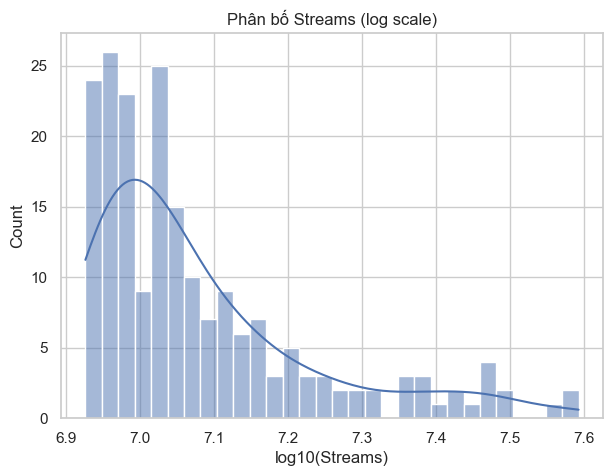

In [45]:
plt.figure(figsize=(7,5))

sns.histplot(np.log10(spotify["streams"]), bins=30, kde=True)

plt.title("Phân bố Streams (log scale)")
plt.xlabel("log10(Streams)")

plt.show()

# Weeks on Chart

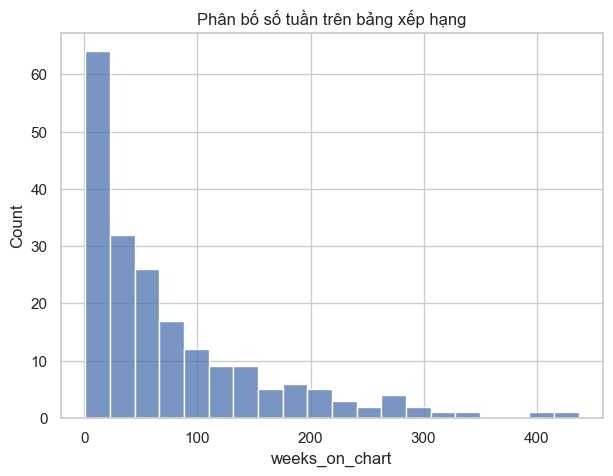

In [47]:
plt.figure(figsize=(7,5))

sns.histplot(spotify["weeks_on_chart"], bins=20)

plt.title("Phân bố số tuần trên bảng xếp hạng")

plt.show()

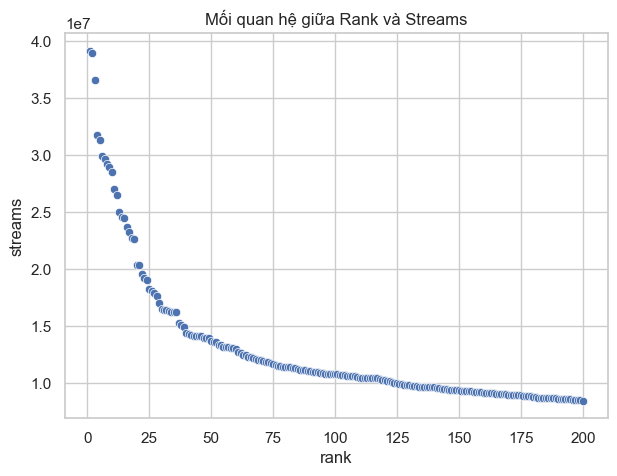

In [48]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=spotify,
    x="rank",
    y="streams"
)

plt.title("Mối quan hệ giữa Rank và Streams")

plt.show()

# VIỆT NAM

In [50]:
spotify_vn = pd.read_json(r"D:\Spotify data\result\VN_1541.json")

spotify_vn.head()

,rank,uri,artist_names,track_name,source,peak_rank,previous_rank,weeks_on_chart,streams
0,1,spotify:track:2HRgqmZQC0MC7GeNuDIXHN,"Jung Kook, Latto",Seven (feat. Latto) (Explicit Ver.),BIGHIT MUSIC,1,1,138,2182315
1,2,spotify:track:1ApIGNgp1azc0qB61x4GzG,"Hngle, Ari",Không Buông,Universal Music Indochina Distributed Labels,2,2,26,1122965
2,3,spotify:track:7uUuftbcr94tzGOCJSM25u,"Low G, JustaTee",In Love,M Music Records,2,3,19,914897
3,4,spotify:track:6GM4ZOBDcDroldUxI8GZ2B,"VSTRA, Tyronee",Ai Ngoài Anh,CDSL,2,4,9,844645
4,5,spotify:track:0t8g66pWghsU8MphjUQIdg,"Phùng Khánh Linh, 30 Pictures",Cảm Ơn Người Đã Thức Cùng Tôi - Original Sound...,+84 Vietnam New Wave,5,56,2,783145


# Xem cấu trúc dữ liệu

In [52]:
spotify_vn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   rank            200 non-null    int64 
 1   uri             200 non-null    object
 2   artist_names    200 non-null    object
 3   track_name      200 non-null    object
 4   source          200 non-null    object
 5   peak_rank       200 non-null    int64 
 6   previous_rank   200 non-null    int64 
 7   weeks_on_chart  200 non-null    int64 
 8   streams         200 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 14.2+ KB


# Thống kê dữ liệu

In [54]:
spotify_vn.describe()

,rank,peak_rank,previous_rank,weeks_on_chart,streams
count,200.000000,200.000000,200.000000,200.000000,2.000000e+02
mean,100.500000,38.430000,82.030000,88.210000,2.824625e+05
std,57.879185,45.977984,58.979931,87.505841,1.962860e+05
min,1.000000,1.000000,-1.000000,1.000000,1.540880e+05
25%,50.750000,4.000000,28.750000,18.000000,1.818075e+05
50%,100.500000,14.500000,79.500000,59.500000,2.204725e+05
75%,150.250000,61.250000,132.250000,135.250000,3.173500e+05
max,200.000000,187.000000,197.000000,413.000000,2.182315e+06


# Làm sạch dữ liệu

In [56]:
spotify_vn["streams"] = spotify_vn["streams"].astype(int)
spotify_vn["rank"] = spotify_vn["rank"].astype(int)
spotify_vn["weeks_on_chart"] = spotify_vn["weeks_on_chart"].astype(int)

# Phân tích tỉ lệ Source phát hành

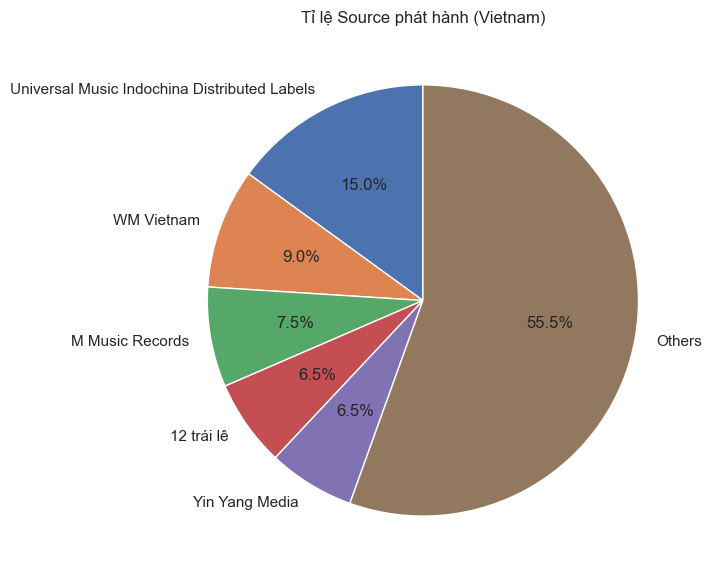

In [58]:
source_counts_vn = spotify_vn["source"].value_counts()

top5 = source_counts_vn.head(5)
others = source_counts_vn[5:].sum()

data = list(top5.values) + [others]
labels = list(top5.index) + ["Others"]

plt.figure(figsize=(7,7))

plt.pie(
    data,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Tỉ lệ Source phát hành (Vietnam)")

plt.show()

##### Biểu đồ thể hiện tỉ lệ nguồn phát hành các bài hát trong bảng xếp hạng Spotify tại Việt Nam. Điều này phản ánh cách các bài hát được phát hành và phổ biến trong thị trường âm nhạc Việt Nam.

# Top 10 bài hát theo số lượt Streams tại Việt Nam


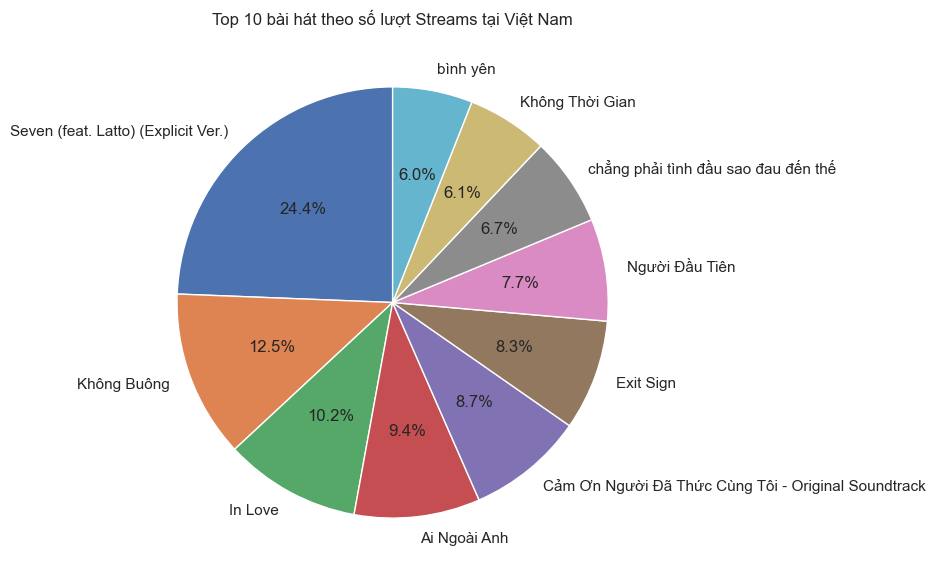

In [61]:
top10_vn = spotify_vn.nlargest(10, "streams")

plt.figure(figsize=(7,7))

plt.pie(
    top10_vn["streams"],
    labels=top10_vn["track_name"],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Top 10 bài hát theo số lượt Streams tại Việt Nam")

plt.show()

##### Top 10 bài hát có số lượt streams cao nhất tại Việt Nam thể hiện xu hướng nghe nhạc của người dùng Spotify trong nước.

# Nghệ sĩ có nhiều bài hát trên chart

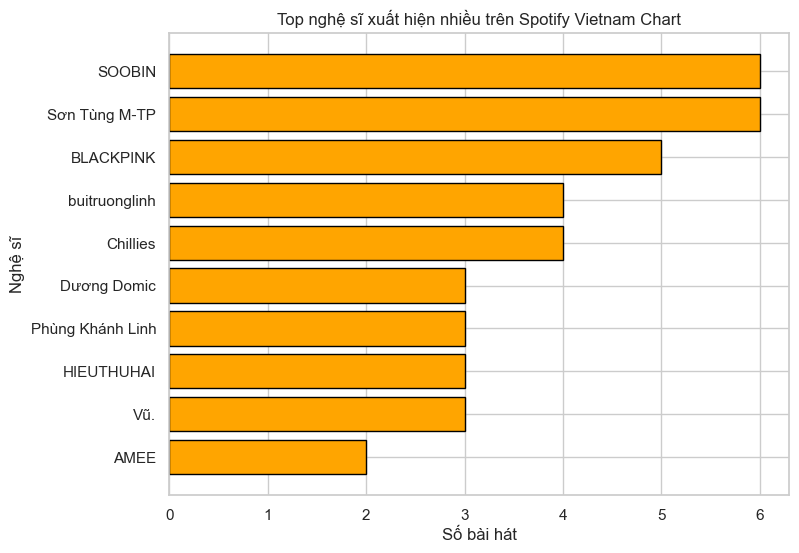

In [64]:
artist_count_vn = spotify_vn["artist_names"].value_counts().head(10)

plt.figure(figsize=(8,6))

plt.barh(
    artist_count_vn.index,
    artist_count_vn.values,
    color="orange",
    edgecolor="black"
)

plt.title("Top nghệ sĩ xuất hiện nhiều trên Spotify Vietnam Chart")
plt.xlabel("Số bài hát")
plt.ylabel("Nghệ sĩ")

plt.gca().invert_yaxis()

plt.show()

# Phân bố Streams

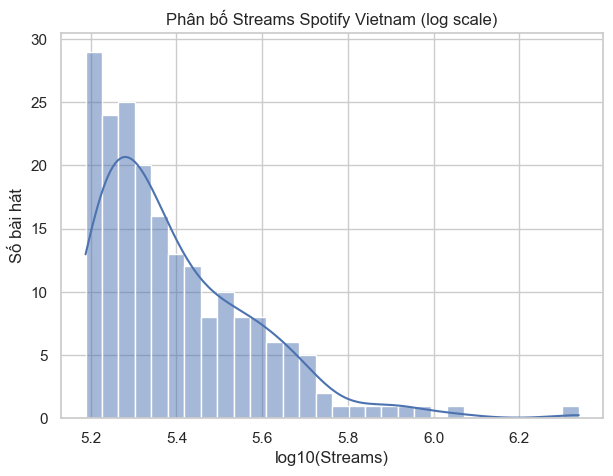

In [66]:
plt.figure(figsize=(7,5))

sns.histplot(np.log10(spotify_vn["streams"]), bins=30, kde=True)

plt.title("Phân bố Streams Spotify Vietnam (log scale)")
plt.xlabel("log10(Streams)")
plt.ylabel("Số bài hát")

plt.show()

# Số bài hát theo tuần 

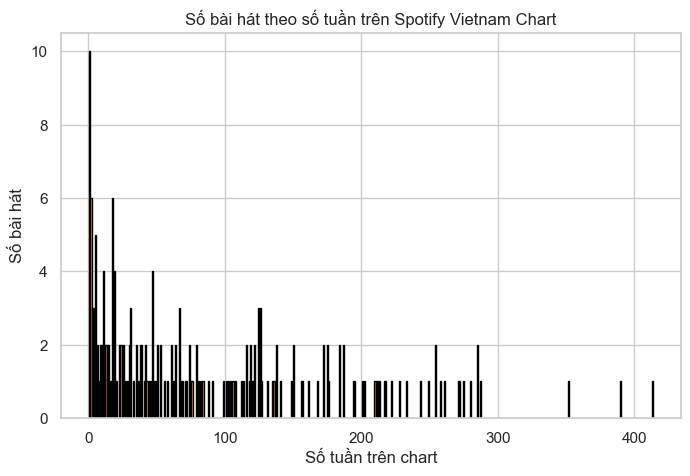

In [68]:
weeks_count_vn = spotify_vn["weeks_on_chart"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(
    weeks_count_vn.index,
    weeks_count_vn.values,
    color="orange",
    edgecolor="black"
)

plt.title("Số bài hát theo số tuần trên Spotify Vietnam Chart")
plt.xlabel("Số tuần trên chart")
plt.ylabel("Số bài hát")

plt.show()

# Các bài hát xuất hiện ở cả Global và Việt Nam

In [70]:
common_tracks = set(spotify["track_name"]) & set(spotify_vn["track_name"])
num_common = len(common_tracks)

In [71]:
common_tracks

{'APT.',
 'Champion',
 'Die With A Smile',
 'GO',
 'I Thought I Saw Your Face Today',
 'JUMP',
 'Me and my',
 'One Of The Girls (with JENNIE, Lily Rose Depp)',
 'Ordinary',
 'Perfect',
 'Risk It All',
 'Seven (feat. Latto) (Explicit Ver.)',
 'Stateside + Zara Larsson',
 "We Don't Talk Anymore (feat. Selena Gomez)",
 'like JENNIE'}

In [72]:
print("Số bài hát trùng:", num_common)

Số bài hát trùng: 15


## Biểu đồ tỉ lệ bài hát chung giữa Global và Vietnam


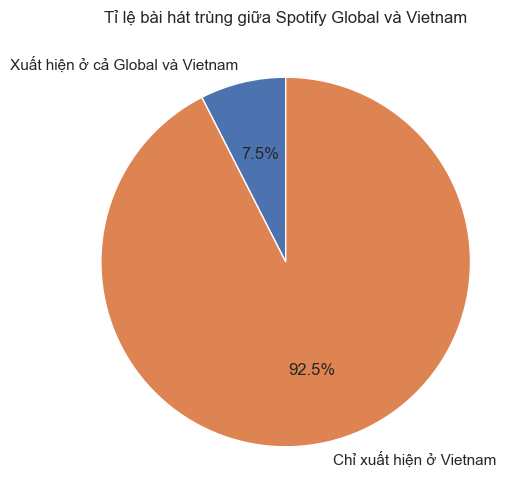

In [74]:
data = [
    num_common,
    len(spotify_vn) - num_common
]

labels = [
    "Xuất hiện ở cả Global và Vietnam",
    "Chỉ xuất hiện ở Vietnam"
]

plt.figure(figsize=(6,6))

plt.pie(
    data,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Tỉ lệ bài hát trùng giữa Spotify Global và Vietnam")

plt.show()

##### Kết quả cho thấy một số bài hát xuất hiện ở cả hai bảng xếp hạng Global và Việt Nam. Điều này cho thấy xu hướng âm nhạc toàn cầu có ảnh hưởng nhất định đến thị hiếu nghe nhạc tại Việt Nam.

# Kết luận


##### Qua quá trình phân tích dữ liệu từ bảng xếp hạng Spotify Global và Spotify Vietnam, có thể rút ra một số nhận định quan trọng về xu hướng nghe nhạc hiện nay. Các bài hát có số lượt streams cao thường là những bản hit được quảng bá rộng rãi và có sức ảnh hưởng lớn trên nền tảng Spotify. Một số nghệ sĩ xuất hiện nhiều lần trong bảng xếp hạng, cho thấy họ có nhiều sản phẩm âm nhạc được người nghe yêu thích và có vị trí quan trọng trong thị trường âm nhạc.

Khi so sánh giữa bảng xếp hạng Global và Vietnam, có thể thấy rằng một số bài hát phổ biến trên toàn cầu cũng xuất hiện trong bảng xếp hạng tại Việt Nam. Điều này phản ánh sự ảnh hưởng của xu hướng âm nhạc quốc tế đối với thị hiếu của người nghe tại Việt Nam trong thời đại toàn cầu hóa và sự phát triển của các nền tảng streaming.

Tuy nhiên, bảng xếp hạng Spotify tại Việt Nam vẫn thể hiện những đặc điểm riêng, phản ánh thị hiếu và văn hóa âm nhạc của người nghe trong nước. Điều này cho thấy mặc dù âm nhạc quốc tế có ảnh hưởng mạnh, nhưng thị trường âm nhạc Việt Nam vẫn duy trì những xu hướng riêng biệt.

Từ kết quả phân tích, có thể thấy rằng dữ liệu từ các nền tảng streaming như Spotify đóng vai trò quan trọng trong việc phản ánh xu hướng nghe nhạc của người dùng. Việc phân tích dữ liệu này không chỉ giúp hiểu rõ hơn về sự phổ biến của các bài hát và nghệ sĩ mà còn giúp nhận diện xu hướng âm nhạc trong từng khu vực và trên toàn cầu.